<a href="https://colab.research.google.com/github/epleywin/ECON3916-Statistical-Machine-Learning/blob/main/Project%201/%20Phase_4_Epley_Win.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: Econometric Analysis of Resume Callback Outcomes

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
df = pd.read_csv("resume.csv")

df.head()

,job_ad_id,job_city,job_industry,job_type,job_fed_contractor,job_equal_opp_employer,job_ownership,job_req_any,job_req_communication,job_req_education,...,honors,worked_during_school,years_experience,computer_skills,special_skills,volunteer,military,employment_holes,has_email_address,resume_quality
0,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,0,6,1,0,0,0,1,0,low
1,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,1,6,1,0,1,1,0,1,high
2,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,1,6,1,0,0,0,0,0,low
3,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,0,6,1,1,1,0,1,1,high
4,385,Chicago,other_service,secretary,0.0,1,nonprofit,1,0,0,...,0,1,22,1,0,0,0,0,1,high


## Table 1: Summary Statistics

In [ ]:
df['race_black'] = (df['race'] == 'black').astype(int)
df['high_quality'] = (df['resume_quality'] == 'high').astype(int)

summary_stats = df[[
    "received_callback",
    "race_black",
    "high_quality",
    "years_experience",
    "college_degree"
]].describe()

print(summary_stats)

       received_callback   race_black  high_quality  years_experience  \
count        4870.000000  4870.000000   4870.000000       4870.000000   
mean            0.080493     0.500000      0.502259          7.842916   
std             0.272083     0.500051      0.500046          5.044612   
min             0.000000     0.000000      0.000000          1.000000   
25%             0.000000     0.000000      0.000000          5.000000   
50%             0.000000     0.500000      1.000000          6.000000   
75%             0.000000     1.000000      1.000000          9.000000   
max             1.000000     1.000000      1.000000         44.000000   

       college_degree  
count     4870.000000  
mean         0.719507  
std          0.449286  
min          0.000000  
25%          0.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [ ]:
# Summary by race (better for analysis)
summary_by_race = df.groupby("race_black")[[
    "received_callback",
    "high_quality",
    "years_experience",
    "college_degree"
]].mean()

print(summary_by_race)

            received_callback  high_quality  years_experience  college_degree
race_black                                                                   
0                    0.096509      0.502259          7.856263        0.716222
1                    0.064476      0.502259          7.829569        0.722793


## Baseline Model

In [ ]:
# Baseline Model (Final)
final_model = smf.ols(
    formula="received_callback ~ race_black + high_quality + years_experience + college_degree",
    data=df
).fit(cov_type="HC1")

print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:      received_callback   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     8.178
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.44e-06
Time:                        14:58:40   Log-Likelihood:                -551.91
No. Observations:                4870   AIC:                             1114.
Df Residuals:                    4865   BIC:                             1146.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.0687      0.011  

## Interaction Model

In [ ]:
# Interaction Model (Final)
final_interaction_model = smf.ols(
    formula="received_callback ~ race_black * high_quality + years_experience + college_degree",
    data=df
).fit(cov_type="HC1")

print(final_interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:      received_callback   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     6.695
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           3.18e-06
Time:                        14:58:42   Log-Likelihood:                -551.26
No. Observations:                4870   AIC:                             1115.
Df Residuals:                    4864   BIC:                             1153.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

## Model Diagnostics: Residual Analysis

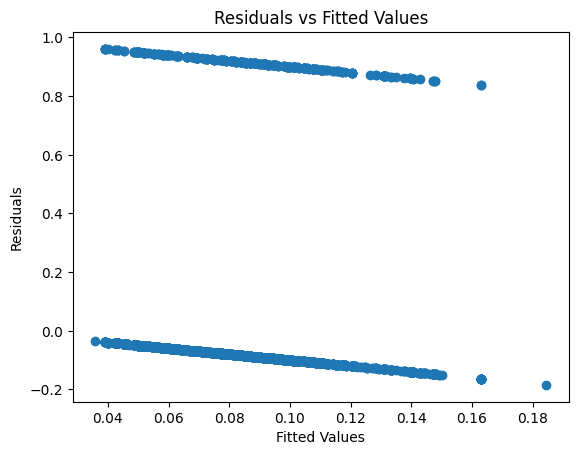

In [ ]:
import matplotlib.pyplot as plt

fitted_vals = final_model.fittedvalues
residuals = final_model.resid

plt.scatter(fitted_vals, residuals)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

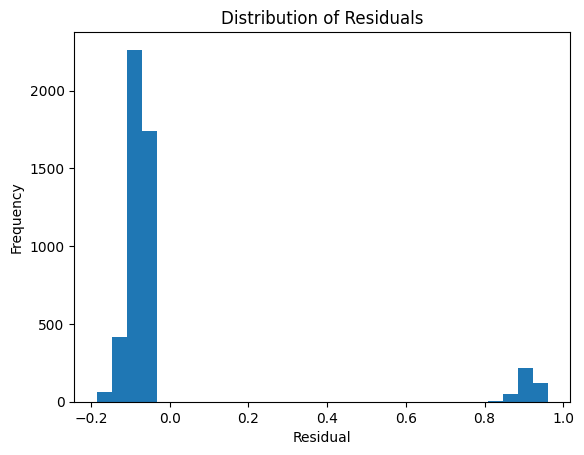

In [ ]:
plt.hist(residuals, bins=30)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

## Robustness Check


In [ ]:
df_robust = df[df["years_experience"] < 20]

robust_model = smf.ols(
    formula="received_callback ~ race_black + high_quality + years_experience + college_degree",
    data=df_robust
).fit(cov_type="HC1")

print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:      received_callback   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     7.410
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           6.03e-06
Time:                        14:58:48   Log-Likelihood:                -477.33
No. Observations:                4659   AIC:                             964.7
Df Residuals:                    4654   BIC:                             996.9
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.0625      0.012  

## Table 2: Regression Results

In [ ]:
from statsmodels.iolib.summary2 import summary_col

table_2 = summary_col(
    [final_model, final_interaction_model, robust_model],
    stars=True,
    model_names=["Baseline", "Interaction", "Robustness"]
)

print(table_2)


                         Baseline  Interaction Robustness
---------------------------------------------------------
Intercept               0.0687***  0.0643***   0.0625*** 
                        (0.0109)   (0.0115)    (0.0117)  
race_black              -0.0319*** -0.0230**   -0.0317***
                        (0.0078)   (0.0106)    (0.0079)  
high_quality            0.0112     0.0201*     0.0083    
                        (0.0077)   (0.0120)    (0.0078)  
years_experience        0.0032***  0.0032***   0.0041*** 
                        (0.0008)   (0.0008)    (0.0011)  
college_degree          -0.0042    -0.0042     -0.0019   
                        (0.0087)   (0.0087)    (0.0088)  
race_black:high_quality            -0.0177               
                                   (0.0155)              
R-squared               0.0077     0.0080      0.0072    
R-squared Adj.          0.0069     0.0069      0.0064    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01
